In [6]:
import numpy as np

d = {
    'apple' : 100,
    'banana' : 200,
    'cherry' : 300,
    'durian' : 400
}

query = 'banana'
print(d[query])

movie_preference = {
    (8,2,3) : 85,
    (3,9,1) : 70,
    (1,2,9) : 60,
    (5,5,5) : 75,
    (7,6,2) : 80,
    (2,7,6) : 65,
    (9,1,1) : 90
}

new_movie = (6,4,5)

def soft_dictionary(query, dictionary):
    similarity = []
    for key in dictionary:
        s = np.dot(query, key)
        similarity.append(s)
    exp_similarity = np.exp(similarity)
    weights = exp_similarity / np.sum(exp_similarity)
    result = 0
    for weight, value in zip(weights, dictionary.values()):
        result += weight * value
    return result, weights

predicted_rating, weights = soft_dictionary(new_movie, movie_preference)

print(predicted_rating)

for key, weights in zip(movie_preference.keys(), weights):
    print(key, weights)

200
78.66177516400408
(8, 2, 3) 0.004892857758495998
(3, 9, 1) 3.006275708282889e-08
(1, 2, 9) 3.006275708282889e-08
(5, 5, 5) 0.26714098198919833
(7, 6, 2) 0.726164476977943
(2, 7, 6) 0.0017999817779268637
(9, 1, 1) 1.6413709216182614e-06


In [2]:
import torch
import torch.nn.functional as F

K = torch.tensor([
    [8,2,3],
    [3,9,1],
    [1,2,9],
    [5,5,5],
    [7,6,2],
    [2,7,6],
    [9,1,1],
], dtype = torch.float32)

V = torch.tensor([
    [85],
    [70],
    [60],
    [75],
    [80],
    [65],
    [90],

], dtype = torch.float32)

Q = torch.tensor([
    [6,4,5],
    [2,8,3],
    [4,3,7],
], dtype = torch.float32)

def attention(Q, K, V):
    similatity = torch.matmul(Q, K.t())
    weights = F.softmax(similatity, dim = 1)
    output = torch.matmul(weights, V)
    return output, weights

predicted_rating, weights = attention(Q,K,V)

for movie, rating in zip(Q, predicted_rating):
    print('영화: ',movie.numpy())
    print('예츨평점: ', rating.item())

영화:  [6. 4. 5.]
예츨평점:  78.66178131103516
영화:  [2. 8. 3.]
예츨평점:  69.76289367675781
영화:  [4. 3. 7.]
예츨평점:  61.201171875


내적:  -3.221949915847363
스케일링한 내적:  -1.0188700241065505


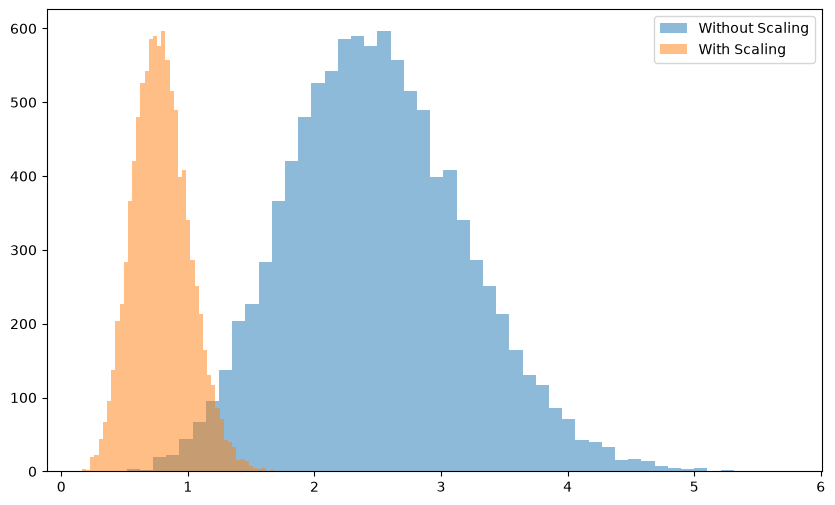

분산(스케일링 없음):  0.4890637659504439
분산(스케일링 적용):  0.048906376595044376


In [3]:
x = torch.tensor([100.0, 200.0, 300.0])
y = F.softmax(x, dim = 0)

import numpy as np
import matplotlib.pyplot as plt

d = 10

q = np.random.randn(d)
k = np.random.randn(d)

dot_product = np.dot(q, k)
scaled_dot_product = dot_product / np.sqrt(d)

print('내적: ', dot_product)
print('스케일링한 내적: ', scaled_dot_product)

d = 10
num_samples = 10000

dot_products = []
scaled_dot_products = []

for _ in range(num_samples):
    q = np.random.rand(d)
    k = np.random.rand(d)

    dot_product = np.dot(q,k)
    scaled_dot_product = dot_product / np.sqrt(d)

    dot_products.append(dot_product)
    scaled_dot_products.append(scaled_dot_product)

plt.figure(figsize= (10,6))
plt.hist(dot_products, bins = 50, alpha = 0.5, label = 'Without Scaling')
plt.hist(scaled_dot_products, bins = 50, alpha = 0.5, label = 'With Scaling')
plt.legend()
plt.show()

print('분산(스케일링 없음): ', np.var(dot_products))
print('분산(스케일링 적용): ', np.var(scaled_dot_products))

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Attention(nn.Module):
    def __init__(self, embed_dim, key_dim):
        super().__init__()
        self.W_q = nn.Linear(embed_dim, key_dim, bias= False)
        self.W_k = nn.Linear(embed_dim, key_dim, bias= False)
        self.W_v = nn.Linear(embed_dim, embed_dim, bias= False)

        self.key_dim = key_dim

    def forward(self, x):
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        K_t = K.transpose(-2, -1)
        scores = torch.matmul(Q, K_t)
        scores = scores / (self.key_dim ** 0.5)

        B, C, E = x.shape
        mask = torch.tril(torch.ones(C, C, device = scores.device))
        scores = scores.masked_fill(mask == 0, float('-inf'))
        weights = F.softmax(scores, dim = -1)
        output = torch.matmul(weights, V)
        return output

attention = Attention(embed_dim= 256, key_dim= 64)
x = torch.randn(2, 5, 256)
y = attention(x)

print('입력 모양: ', x.shape)
print('출력 모양: ', y.shape)

입력 모양:  torch.Size([2, 5, 256])
출력 모양:  torch.Size([2, 5, 256])


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Attention(nn.Module):
    def __init__(self, embed_dim, key_dim):
        super().__init__()
        self.W_q = nn.Linear(embed_dim, key_dim, bias= False)
        self.W_k = nn.Linear(embed_dim, key_dim, bias= False)
        self.W_v = nn.Linear(embed_dim, key_dim, bias= False)
        self.W_o = nn.Linear(key_dim, key_dim, bias= False)
        self.key_dim = key_dim

    def forward(self, x):
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        K_t = K.transpose(-2,-1)
        scores = torch.matmul(Q, K_t)
        scores = scores / (self.key_dim ** 0.5)

        B, C, E = x.shape
        mask = torch.tril(torch.ones(C, C, device = scores.device))
        scores = scores.masked_fill(mask == 0, float('-inf'))

        weights = F.softmax(scores, dim = -1)
        hidden = torch.matmul(weights, V)
        output = self.W_o(hidden)
        return output

attention = Attention(embed_dim= 256, key_dim= 64)
x = torch.randn(2,5,256)
y = attention(x)

print('입력 모양: ', x.shape)
print('출력 모양: ', y.shape)

입력 모양:  torch.Size([2, 5, 256])
출력 모양:  torch.Size([2, 5, 64])


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

B = 2 #Batch_size
C = 4 #Context_len
E = 16 #Embed_dim
H = 3 #num_Head
D = 8 #head_Dim

x = torch.randn(B, C, E)

W_q = nn.Linear(E, H*D, bias= False)
W_k = nn.Linear(E, H*D, bias= False)
W_v = nn.Linear(E, H*D, bias= False)

Q = W_q(x)
K = W_k(x)
V = W_v(x)

Q = Q.view(B, C, H, D).transpose(1,2)
K = K.view(B, C, H, D).transpose(1,2)
V = V.view(B, C, H, D).transpose(1,2)

scores = torch.matmul(Q, K.transpose(-2,-1))
scores = scores / (D ** 0.5)

mask = torch.tril(torch.ones(C, C, device = scores.device))
scores = scores.masked_fill(mask == 0, float('-inf'))

weights = F.softmax(scores, dim = -1)
hidden = torch.matmul(weights, V)

hidden = hidden.transpose(1,2)
hidden = hidden.contiguous().view(B, C, H*D)

W_o = nn.Linear(H*D, E, bias= False)
output = W_o(hidden)

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, n_head, head_dim, dropout_rate = 0.1):
        super().__init__()
        self.n_head = n_head
        self.head_dim = head_dim
        E, H, D = embed_dim, n_head, head_dim

        self.W_q = nn.Linear(E, H*D, bias= False)
        self.W_k = nn.Linear(E, H*D, bias= False)
        self.W_v = nn.Linear(E, H*D, bias= False)
        self.W_o = nn.Linear(H*D, E, bias= False)

        self.attention_dropout = nn.Dropout(dropout_rate)
        self.output_dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        B,C,E = x.shape
        H,D = self.n_head, self.head_dim

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        Q = Q.view(B,C,H,D).transpose(1,2)
        K = K.view(B,C,H,D).transpose(1,2)
        V = V.view(B,C,H,D).transpose(1,2)

        scores = torch.matmul(Q, K.transpose(-2,-1))
        scores = scores / (D ** 0.5)
        mask = torch.tril(torch.ones(C, C, device = scores.device))
        scores = scores.masked_fill(mask == 0, float('-inf'))

        weights = F.softmax(scores, dim = -1)
        weights = self.attention_dropout(weights)
        hidden = torch.matmul(weights, V)

        hidden = hidden.transpose(1,2).contiguous()
        hidden = hidden.view(B,C,H*D)
        output = self.W_o(hidden)
        output = self.output_dropout(output)

        return output

embed_dim = 512
n_head = 8
head_dim = 64

mha = MultiHeadAttention(embed_dim, n_head, head_dim)
batch_size = 2
context_len = 10
x = torch.randn(batch_size, context_len, embed_dim)

output = mha(x)
print('입력: ', x.shape)
print('출력: ', output.shape)

입력:  torch.Size([2, 10, 512])
출력:  torch.Size([2, 10, 512])


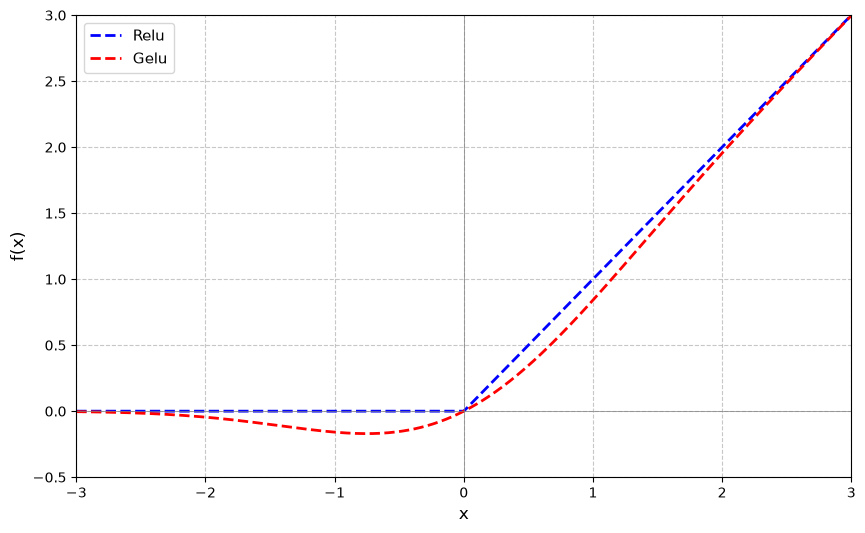

In [14]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-3,3,500)
relu = np.maximum(0,x)
gelu = 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x **3)))

fig, ax = plt.subplots(figsize = (10,6))
ax.plot(x, relu, 'b--', linewidth = 2, label = 'Relu')
ax.plot(x, gelu, 'r--', linewidth = 2, label = 'Gelu')
ax.set_xlim(-3,3)
ax.set_ylim(-0.5, 3.0)
ax.set_xlabel('x', fontsize = 12)
ax.set_ylabel('f(x)', fontsize = 12)
ax.grid(True, linestyle = '--', alpha = 0.7)
ax.axhline(y = 0, color = 'gray', linewidth = 0.5)
ax.axvline(x = 0, color = 'gray', linewidth = 0.5)
ax.legend(loc = 'upper left', fontsize = 11)
plt.tight_layout()
plt.show()